<a href="https://colab.research.google.com/github/pratik5355/email-spam-classifier/blob/main/email_spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
DATASET_URL = "/content/spam_assassin.csv"

In [2]:
TEXT_COLUMN   = "text"
TARGET_COLUMN = "target"
TEST_SIZE     = 0.2
RANDOM_STATE  = 42
MAX_FEATURES  = 5000

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)

In [4]:
#  1.  LOAD DATA

def load_data(url: str) -> pd.DataFrame:
    print(f"\n{'='*58}")
    print("  STEP 1 — Loading dataset")
    print(f"{'='*58}")

    df = pd.read_csv(url, encoding='latin-1')

    print(f"  Loaded {df.shape[0]} rows × {df.shape[1]} columns")
    print("  Columns:", df.columns.tolist())

    return df

In [6]:
#  2.  EXPLORE DATA
def explore_data(df: pd.DataFrame) -> None:
    print(f"\n{'='*58}")
    print("  STEP 2 — Exploratory Data Analysis")
    print(f"{'='*58}")

    print(f"\n  Total emails     : {len(df)}")
    spam_count = df[TARGET_COLUMN].sum()
    ham_count  = len(df) - spam_count
    print(f"  Spam (1)         : {spam_count} ({spam_count/len(df)*100:.1f}%)")
    print(f"  Ham  (0)         : {ham_count}  ({ham_count/len(df)*100:.1f}%)")

    missing = df[TEXT_COLUMN].isnull().sum()
    print(f"  Missing text rows: {missing}")

    df["email_length"] = df[TEXT_COLUMN].astype(str).apply(len)

    print(f"\n  Avg email length (spam): {df[df[TARGET_COLUMN]==1]['email_length'].mean():.0f} chars")
    print(f"  Avg email length (ham) : {df[df[TARGET_COLUMN]==0]['email_length'].mean():.0f} chars")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(["Ham (0)", "Spam (1)"], [ham_count, spam_count],
                color=["#4CAF50", "#E53935"], edgecolor="white", width=0.5)
    axes[0].set_title("Class Distribution", fontweight="bold")

    axes[1].boxplot(
        [df[df[TARGET_COLUMN]==0]["email_length"],
         df[df[TARGET_COLUMN]==1]["email_length"]],
        labels=["Ham", "Spam"],
        patch_artist=True
    )

    plt.tight_layout()
    plt.savefig("spam_eda.png", dpi=150)
    plt.show()

In [8]:
#  3.  PREPROCESS TEXT

def clean_text(text: str) -> str:
    text = str(text).lower()

    text = re.sub(r"from\s+\S+", " ", text)  # ✅ ADDED (important)

    text = re.sub(r"http\S+|www\S+", " url ", text)
    text = re.sub(r"\S+@\S+", " email ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def preprocess(df: pd.DataFrame):
    print(f"\n{'='*58}")
    print("  STEP 3 — Preprocessing")
    print(f"{'='*58}")

    df = df.dropna(subset=[TEXT_COLUMN, TARGET_COLUMN]).copy()
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

    df["clean_text"] = df[TEXT_COLUMN].apply(clean_text)

    X = df["clean_text"]
    y = df[TARGET_COLUMN]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    vectorizer = TfidfVectorizer(
        max_features=MAX_FEATURES,
        stop_words="english",
        ngram_range=(1, 2),
        sublinear_tf=True
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec  = vectorizer.transform(X_test)

    return X_train_vec, X_test_vec, y_train, y_test, vectorizer

In [10]:
#  4.  TRAIN
def train(X_train_vec, y_train):
    print(f"\n{'='*58}")
    print("  STEP 4 — Training")
    print(f"{'='*58}")

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)

    scores = cross_val_score(model, X_train_vec, y_train, cv=5, scoring="f1")
    print(f"  CV F1 Score: {scores.mean():.4f}")

    return model

In [11]:
#  5.  EVALUATE

def evaluate(model, X_test_vec, y_test):
    print(f"\n{'='*58}")
    print("  STEP 5 — Evaluation")
    print(f"{'='*58}")

    y_pred = model.predict(X_test_vec)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))

    print("\n", classification_report(y_test, y_pred))


  STEP 1 — Loading dataset
  Loaded 5796 rows × 2 columns
  Columns: ['text', 'target']

  STEP 2 — Exploratory Data Analysis

  Total emails     : 5796
  Spam (1)         : 1896 (32.7%)
  Ham  (0)         : 3900  (67.3%)
  Missing text rows: 0

  Avg email length (spam): 5667 chars
  Avg email length (ham) : 3483 chars


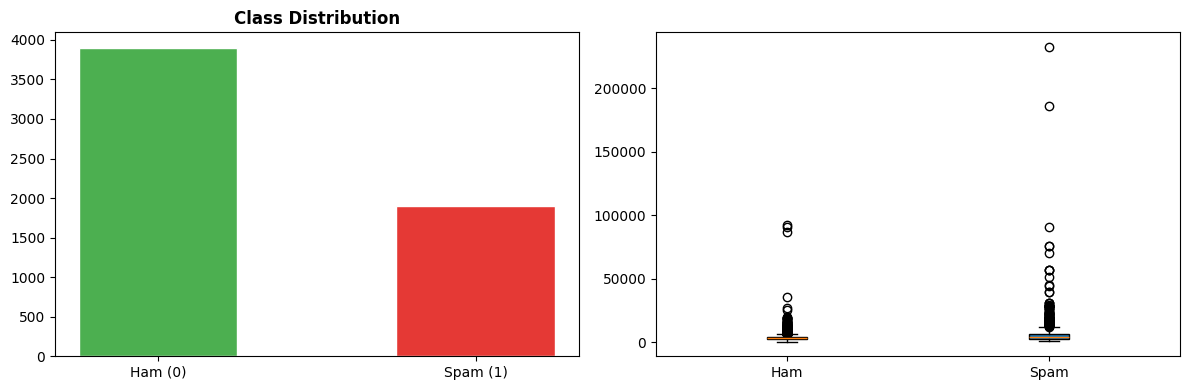


  STEP 3 — Preprocessing

  STEP 4 — Training
  CV F1 Score: 0.9765

  STEP 5 — Evaluation
Accuracy: 0.9793103448275862
Precision: 0.9916897506925207
Recall: 0.9445910290237467
F1: 0.9675675675675676

               precision    recall  f1-score   support

           0       0.97      1.00      0.98       781
           1       0.99      0.94      0.97       379

    accuracy                           0.98      1160
   macro avg       0.98      0.97      0.98      1160
weighted avg       0.98      0.98      0.98      1160



In [12]:
def main():
    df = load_data(DATASET_URL)
    explore_data(df)

    X_train_vec, X_test_vec, y_train, y_test, vectorizer = preprocess(df)

    model = train(X_train_vec, y_train)

    evaluate(model, X_test_vec, y_test)


if __name__ == "__main__":
    main()